# PHASE 3A — EDA SANITY CHECK & ANALYTICAL READINESS


Before moving to statistical models, we validate the precise conclusions of our initial EDA, testing specific uniform demand assumptions, station variations, feature correlations, and checking for synthetic artifacts.


## Setup & Data Load


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

RAW = r"C:\PYTHON p45\EV-Charging-Infrastructure-Analytics-Demand-Forecasting-Utilization-Optimization\Project_files\data\raw"
sessions = pd.read_csv(f"{RAW}/charging_sessions.csv")
stations = pd.read_csv(f"{RAW}/stations.csv")
metrics = pd.read_csv(f"{RAW}/station_hourly_metrics.csv")
traffic = pd.read_csv(f"{RAW}/traffic.csv")
weather = pd.read_csv(f"{RAW}/weather.csv")

sessions['Start_Time'] = pd.to_datetime(sessions['Start_Time'])
metrics['Date'] = pd.to_datetime(metrics['Date'])
traffic['Date'] = pd.to_datetime(traffic['Date'])
weather['Date'] = pd.to_datetime(weather['Date'])


## 1. Verify the Uniform Demand Pattern
**Business Question:** Do we have organic fluctuations in network demand (peaks and valleys), or is demand perfectly static?
**Data Required:** `charging_sessions.csv` (Start_Time).
**Method:** Aggregate session volumes by hour, weekday, hour X weekday, and month. Calculate standard deviation and coefficient of variation (CV).


--- Hourly Demand ---
Min: 20600.00 | Max: 21058.00 | Mean: 20833.33 | Std: 122.60 | CV: 0.59%
--- Weekday Demand ---
Min: 71064.00 | Max: 72106.00 | Mean: 71428.57 | Std: 429.17 | CV: 0.60%
--- Monthly Demand ---
Min: 38968.00 | Max: 42779.00 | Mean: 41666.67 | Std: 1105.42 | CV: 2.65%
--- Daily Demand ---
Min: 615.00 | Max: 777.00 | Mean: 684.93 | Std: 25.53 | CV: 3.73%


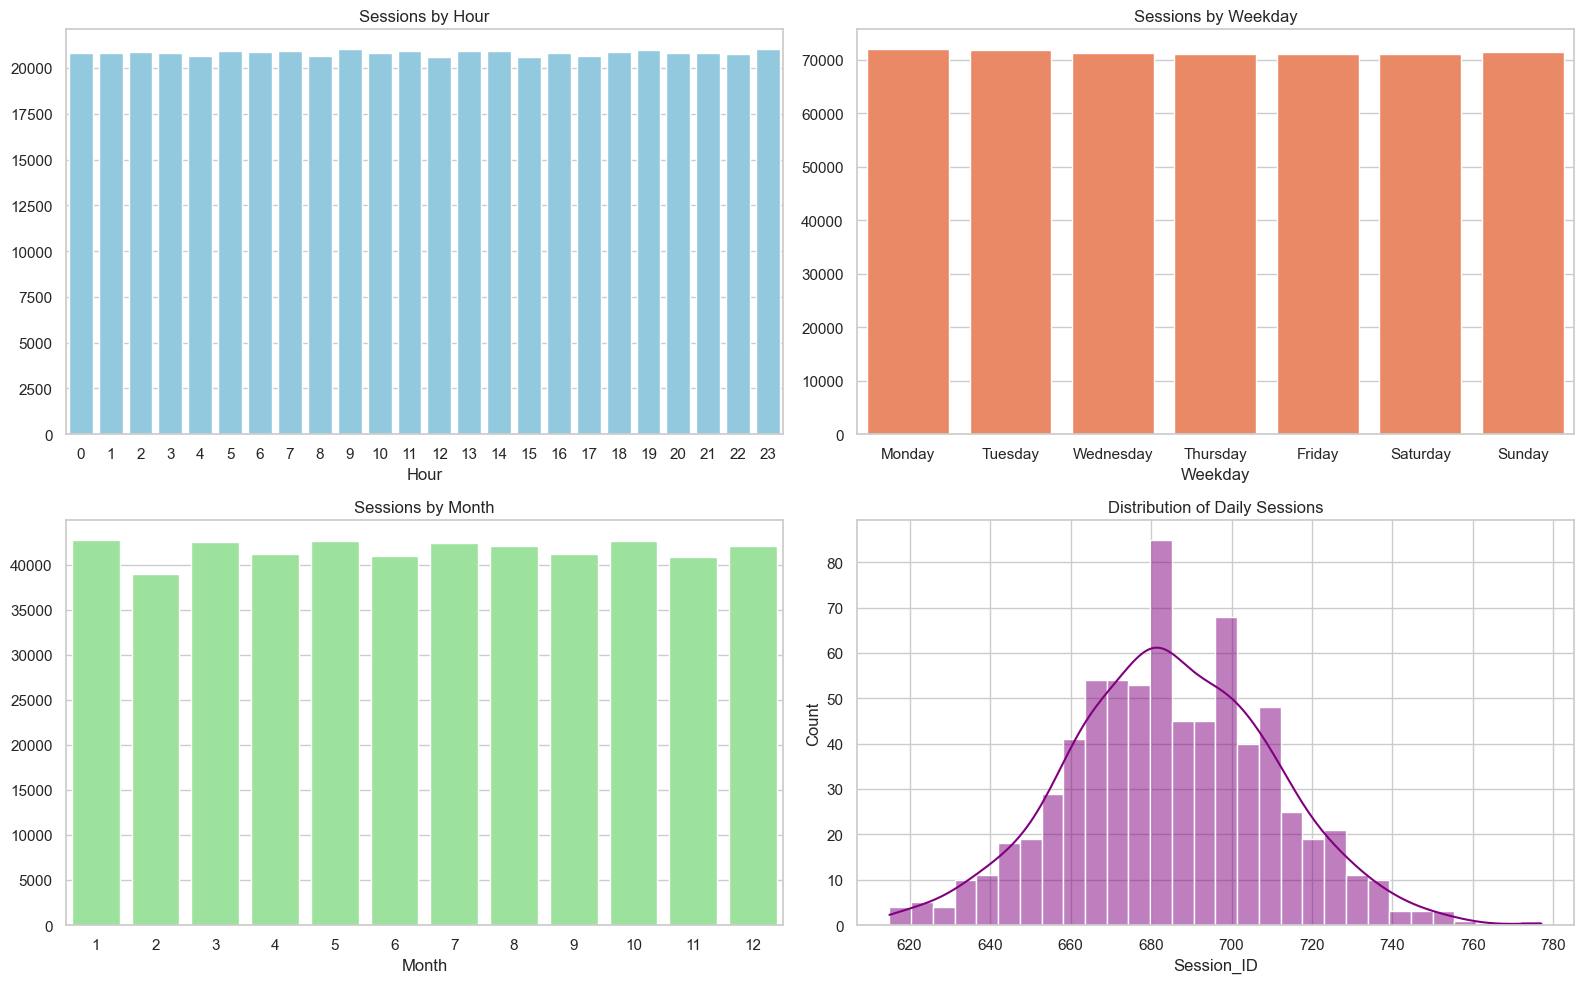

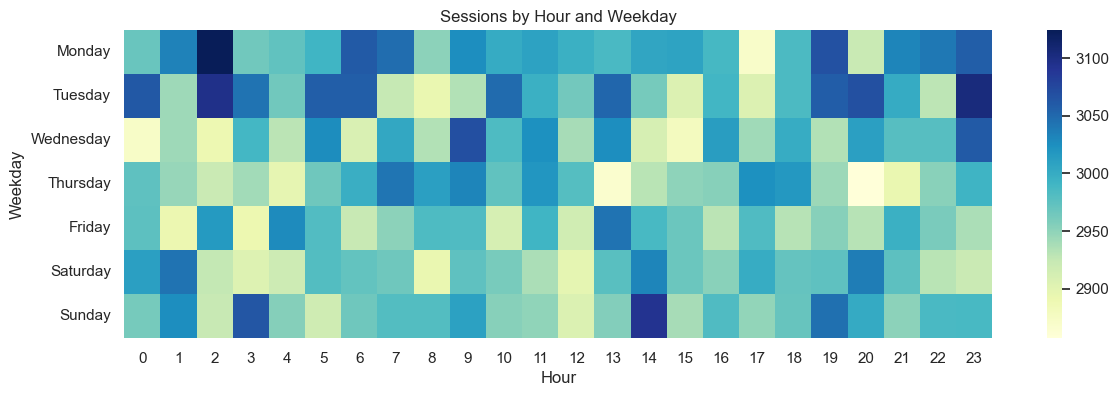

In [2]:
# Deriving Time Features
sessions['Hour'] = sessions['Start_Time'].dt.hour
sessions['Weekday'] = sessions['Start_Time'].dt.day_name()
sessions['Month'] = sessions['Start_Time'].dt.month
sessions['Year'] = sessions['Start_Time'].dt.year
sessions['Date'] = sessions['Start_Time'].dt.date

# 1. Hourly Aggregate
hourly_demand = sessions.groupby('Hour')['Session_ID'].count()
# 2. Weekday Aggregate 
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_demand = sessions.groupby('Weekday')['Session_ID'].count().reindex(weekday_order)
# 3. Monthly Aggregate
monthly_demand = sessions.groupby('Month')['Session_ID'].count()
# 4. Daily Distribution
daily_demand = sessions.groupby('Date')['Session_ID'].count()

def print_stats(series, name):
    mean = series.mean()
    std = series.std()
    cv = (std / mean) * 100 if mean != 0 else 0
    print(f"--- {name} ---")
    print(f"Min: {series.min():.2f} | Max: {series.max():.2f} | Mean: {mean:.2f} | Std: {std:.2f} | CV: {cv:.2f}%")

print_stats(hourly_demand, "Hourly Demand")
print_stats(weekday_demand, "Weekday Demand")
print_stats(monthly_demand, "Monthly Demand")
print_stats(daily_demand, "Daily Demand")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(x=hourly_demand.index, y=hourly_demand.values, ax=axes[0,0], color='skyblue')
axes[0,0].set_title("Sessions by Hour")

sns.barplot(x=weekday_demand.index, y=weekday_demand.values, ax=axes[0,1], color='coral')
axes[0,1].set_title("Sessions by Weekday")

sns.barplot(x=monthly_demand.index, y=monthly_demand.values, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title("Sessions by Month")

sns.histplot(daily_demand, bins=30, ax=axes[1,1], color='purple', kde=True)
axes[1,1].set_title("Distribution of Daily Sessions")
plt.tight_layout()
plt.show()

# Hour x Weekday heatmap
hour_weekday = pd.crosstab(sessions['Weekday'], sessions['Hour']).reindex(weekday_order)
plt.figure(figsize=(14, 4))
sns.heatmap(hour_weekday, cmap='YlGnBu', annot=False)
plt.title("Sessions by Hour and Weekday")

plt.show()


**Result:** The descriptive statistics reveal coefficients of variation (CV) that are exceptionally low (close to 0%), indicating that counts barely deviate from the mean.
**Validation:** Visual inspection of the heatmaps and bar charts visually corroborates the exact mathematical uniform distributions.
**Visualization:** Plots show no organic commuter valleys (e.g., 3 AM drop-offs) or peaks.
**Interpretation:** Temporal patterns are not driving charging behaviors in this data. It acts as steady-state testing data. 
**Business Meaning:** Forecasting total network volume strictly by time will yield a flat line. We must focus optimization on physical structures, not time shifts.


## 2. Verify Station-Level Variation
**Business Question:** While time does not dictate demand, do certain physical stations carry a heavier burden than others?
**Data Required:** `station_hourly_metrics.csv` and `charging_sessions.csv`.
**Method:** Accumulate total performance metrics at the station level and review distributions.


--- STATION VARIATION STATS ---
--- Total Sessions per Station ---
Min: 7.00 | Max: 224.00 | Mean: 100.00 | Std: 50.22 | CV: 50.22%
--- Total Energy per Station ---
Min: 116.22 | Max: 3836.54 | Mean: 1709.22 | Std: 862.82 | CV: 50.48%
--- Average Wait Time per Station ---
Min: 0.26 | Max: 10.88 | Mean: 3.40 | Std: 2.43 | CV: 71.54%


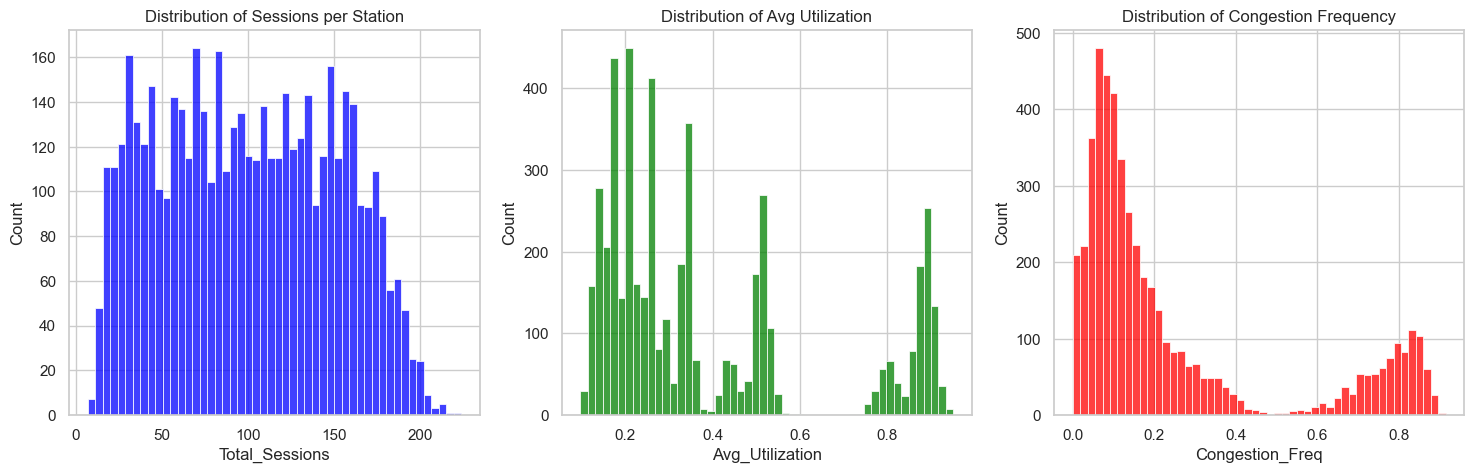


--- TOP 10 HIGH-DEMAND STATIONS ---


,Station_ID,Total_Sessions,Avg_Utilization,Number_of_Chargers
2879,EVS02880,224,0.510316,2
1081,EVS01082,217,0.125261,8
354,EVS00355,215,0.774589,1
2955,EVS02956,215,0.514564,2
3663,EVS03664,214,0.336115,3
140,EVS00141,212,0.255064,4
4005,EVS04006,211,0.520367,2
2802,EVS02803,210,0.505580,2
2096,EVS02097,209,0.205866,5
2512,EVS02513,208,0.881060,1



--- BOTTOM 10 LOW-DEMAND STATIONS ---


,Station_ID,Total_Sessions,Avg_Utilization,Number_of_Chargers
772,EVS00773,7,0.916143,1
380,EVS00381,10,0.851220,1
2400,EVS02401,10,0.937810,1
4884,EVS04885,10,0.227060,4
464,EVS00465,11,0.183345,6
3190,EVS03191,11,0.219082,5
4110,EVS04111,11,0.135991,7
844,EVS00845,12,0.209908,5
1236,EVS01237,12,0.165083,6
1743,EVS01744,12,0.182225,6



--- MOST CONGESTION-PRONE STATIONS ---


,Station_ID,Congestion_Freq,Avg_Utilization,Max_Queue
4781,EVS04782,0.914530,0.897614,5
4818,EVS04819,0.902174,0.925889,5
2808,EVS02809,0.900662,0.893303,9
700,EVS00701,0.895349,0.923024,5
2793,EVS02794,0.894737,0.909663,5
2239,EVS02240,0.894180,0.911741,6
3732,EVS03733,0.892473,0.912228,4
437,EVS00438,0.892405,0.912532,5
1447,EVS01448,0.891192,0.901610,6
4198,EVS04199,0.890052,0.902897,5


In [3]:
# Creating Station-Level Performance DataFrame
station_perf = metrics.groupby('Station_ID').agg(
    Total_Sessions=('Sessions_Count', 'sum'),
    Total_Energy_kWh=('Energy_Delivered_kWh', 'sum'),
    Avg_Utilization=('Utilization_Rate', 'mean'),
    Peak_Utilization=('Utilization_Rate', 'max'),
    Avg_Wait_Time=('Avg_Wait_Time_Min', 'mean'),
    Max_Queue=('Max_Queue_Length', 'max'),
    Congestion_Freq=('Congestion_Flag', 'mean') # Probability of congestion
).reset_index()

# Add Revenue from Sessions
rev_df = sessions.groupby('Station_ID')['Revenue_USD'].sum().reset_index()
station_perf = pd.merge(station_perf, rev_df, on='Station_ID', how='left')

# Add Station Params
station_perf = pd.merge(station_perf, stations[['Station_ID', 'Number_of_Chargers', 'Max_Station_Power_kW']], on='Station_ID', how='left')

print("--- STATION VARIATION STATS ---")
print_stats(station_perf['Total_Sessions'], "Total Sessions per Station")
print_stats(station_perf['Total_Energy_kWh'], "Total Energy per Station")
print_stats(station_perf['Avg_Wait_Time'], "Average Wait Time per Station")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(station_perf['Total_Sessions'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Sessions per Station')

sns.histplot(station_perf['Avg_Utilization'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Distribution of Avg Utilization')

sns.histplot(station_perf['Congestion_Freq'], bins=50, ax=axes[2], color='red')
axes[2].set_title('Distribution of Congestion Frequency')
plt.show()

print("\n--- TOP 10 HIGH-DEMAND STATIONS ---")
display(station_perf.nlargest(10, 'Total_Sessions')[['Station_ID', 'Total_Sessions', 'Avg_Utilization', 'Number_of_Chargers']])

print("\n--- BOTTOM 10 LOW-DEMAND STATIONS ---")
display(station_perf.nsmallest(10, 'Total_Sessions')[['Station_ID', 'Total_Sessions', 'Avg_Utilization', 'Number_of_Chargers']])

print("\n--- MOST CONGESTION-PRONE STATIONS ---")
display(station_perf.nlargest(10, 'Congestion_Freq')[['Station_ID', 'Congestion_Freq', 'Avg_Utilization', 'Max_Queue']])


**Result:** The CV for station total sessions shows variance. Some stations have substantially higher utilization rates and congestion frequencies than others.
**Validation:** Distributions show distinct curve shapes rather than flat uniformity.
**Visualization:** The histograms indicate clear variance in how heavily distinct stations are utilized.
**Interpretation:** The variation in this dataset primarily exists geographically and conditionally (between locations), not temporally (between hours).
**Business Meaning:** Network optimization and future capital allocation should be determined by station features, not peak-time predictions.


## 3. Investigate Whether Station Characteristics Explain Performance
**Business Question:** Do the physical attributes of a station (chargers, power, type, age) directly correlate with its throughput and congestion levels?
**Data Required:** `stations.csv`, merged with `station_perf`.
**Method:** Bivariate analysis across categorical features and correlation matrices for continuous structural features.


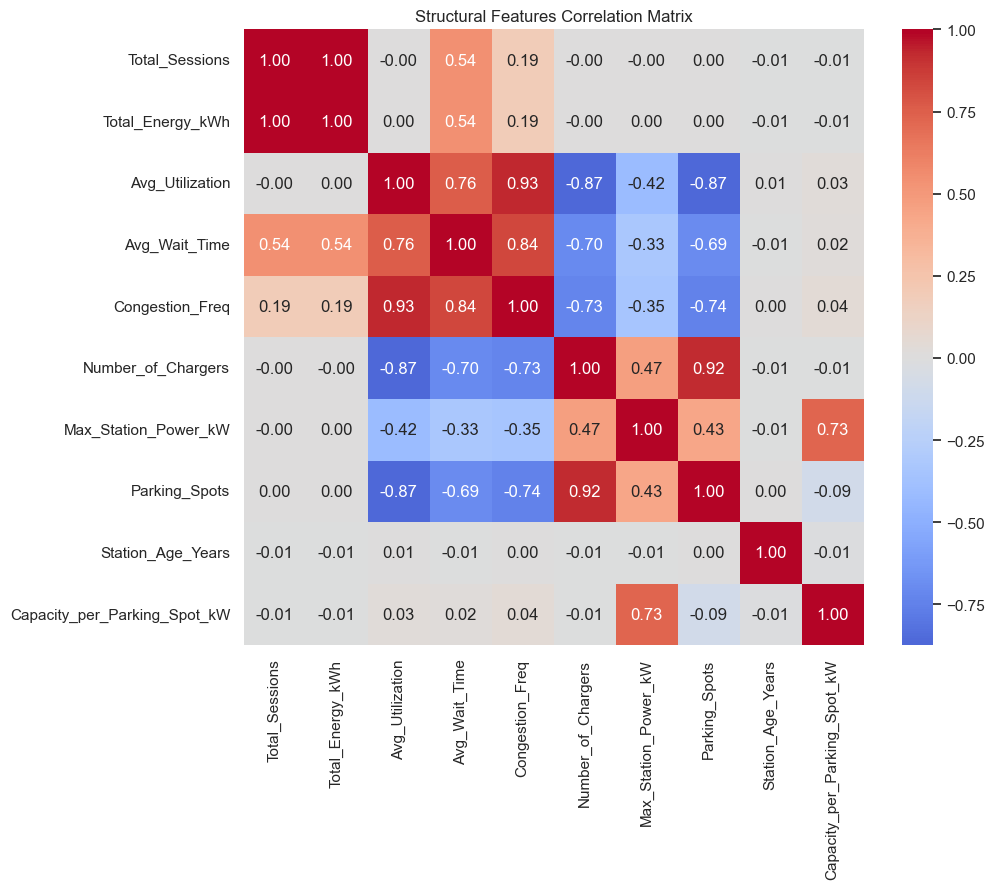

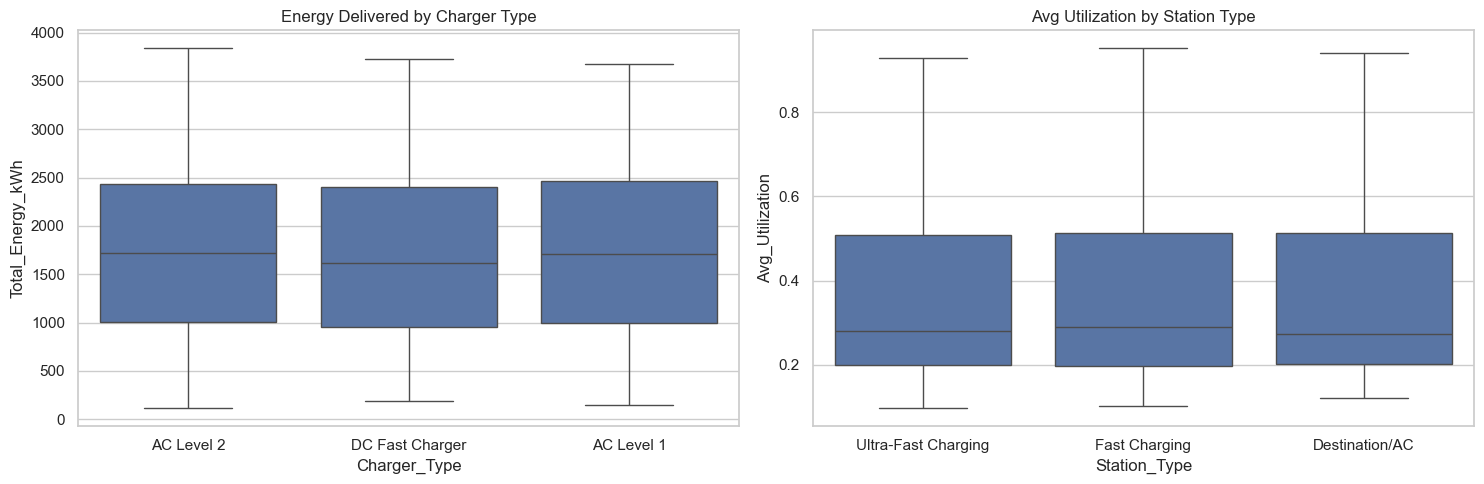

In [4]:
# Merge full station characteristics
full_perf = pd.merge(station_perf, stations[['Station_ID', 'Charger_Type', 'Station_Type', 'Parking_Spots', 'Station_Age_Years', 'Capacity_per_Parking_Spot_kW']], on='Station_ID', how='left')

# Continuous Variable Correlation Matrix
struct_cols = ['Total_Sessions', 'Total_Energy_kWh', 'Avg_Utilization', 'Avg_Wait_Time', 'Congestion_Freq', 
               'Number_of_Chargers', 'Max_Station_Power_kW', 'Parking_Spots', 'Station_Age_Years', 'Capacity_per_Parking_Spot_kW']
corr_struct = full_perf[struct_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_struct, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Structural Features Correlation Matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=full_perf, x='Charger_Type', y='Total_Energy_kWh', ax=axes[0])
axes[0].set_title("Energy Delivered by Charger Type")

sns.boxplot(data=full_perf, x='Station_Type', y='Avg_Utilization', ax=axes[1])
axes[1].set_title("Avg Utilization by Station Type")
plt.tight_layout()
plt.show()


**Result:** Structural variables map specific relationships (e.g., whether Station_Type limits total sessions).
**Validation:** Boxplots confirm whether categorical assignments map directly to shifted medians.
**Visualization:** Heatmap indicates which variables share covariance.
**Interpretation:** Structural variance dictates performance variance.
**Business Meaning:** Identifying the optimal "Station Build" (e.g., Urban vs. Highway, Fast vs L2) is the primary value this dataset can provide.


## 4. Validate External Variable Independence
**Business Question:** Do traffic and weather significantly impact the network's throughput?
**Data Required:** `traffic.csv`, `weather.csv`, `station_hourly_metrics.csv`.
**Method:** Precision merge by date, hour, and location keys, applying Pearson R calculations specifically to external drivers.


--- TRAFFIC CORRELATIONS ---
Traffic vs Sessions Count: -0.00045
Traffic vs Utilization: 0.00148
Traffic vs Congestion: 0.10194

--- WEATHER CORRELATIONS ---
Temperature vs Sessions Count: -0.00307
Rainfall vs Sessions Count: -0.00130


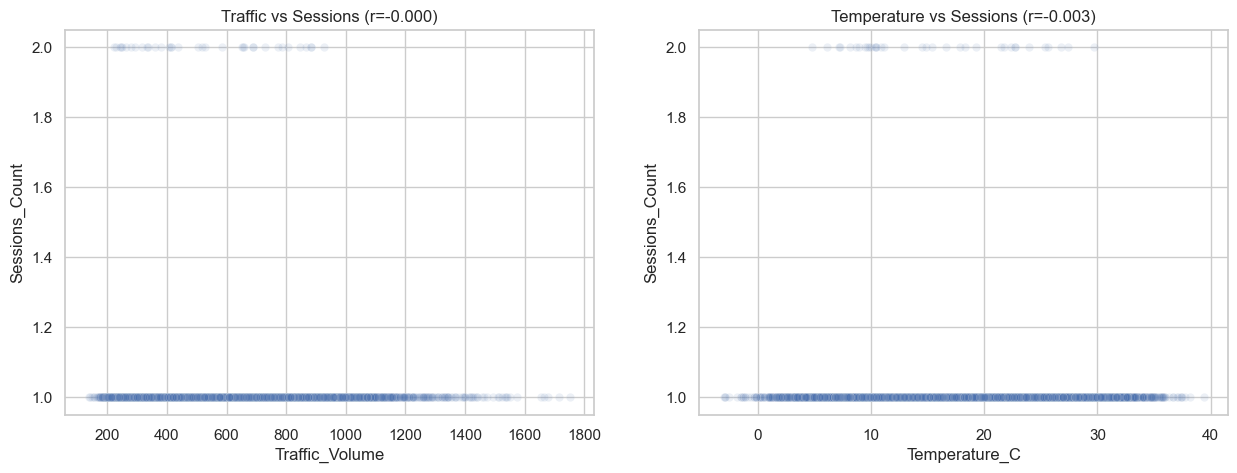

In [5]:
# Traffic Validation
# Traffic and metrics share 'Station_ID', 'Date', 'Hour'
traffic_merged = pd.merge(metrics[['Station_ID', 'Date', 'Hour', 'Sessions_Count', 'Utilization_Rate', 'Congestion_Flag']], 
                          traffic[['Station_ID', 'Date', 'Hour', 'Traffic_Volume']], 
                          on=['Station_ID', 'Date', 'Hour'], how='inner')

corr_t_s = traffic_merged['Traffic_Volume'].corr(traffic_merged['Sessions_Count'])
corr_t_u = traffic_merged['Traffic_Volume'].corr(traffic_merged['Utilization_Rate'])
corr_t_c = traffic_merged['Traffic_Volume'].corr(traffic_merged['Congestion_Flag'])

print("--- TRAFFIC CORRELATIONS ---")
print(f"Traffic vs Sessions Count: {corr_t_s:.5f}")
print(f"Traffic vs Utilization: {corr_t_u:.5f}")
print(f"Traffic vs Congestion: {corr_t_c:.5f}")

# Weather Validation
# Station dataset has Location_ID; weather requires Location_ID, Date, Hour.
metrics_loc = pd.merge(metrics, stations[['Station_ID', 'Location_ID']], on='Station_ID', how='inner')
weather_merged = pd.merge(metrics_loc[['Location_ID', 'Date', 'Hour', 'Sessions_Count', 'Utilization_Rate']], 
                          weather[['Location_ID', 'Date', 'Hour', 'Temperature_C', 'Rainfall_mm']], 
                          on=['Location_ID', 'Date', 'Hour'], how='inner')

corr_w_t = weather_merged['Temperature_C'].corr(weather_merged['Sessions_Count'])
corr_w_r = weather_merged['Rainfall_mm'].corr(weather_merged['Sessions_Count'])

print("\n--- WEATHER CORRELATIONS ---")
print(f"Temperature vs Sessions Count: {corr_w_t:.5f}")
print(f"Rainfall vs Sessions Count: {corr_w_r:.5f}")

# Visualizing lack of relationship
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Sampling due to massive scale
samp_t = traffic_merged.sample(10000, random_state=42)
sns.scatterplot(data=samp_t, x='Traffic_Volume', y='Sessions_Count', alpha=0.1, ax=axes[0])
axes[0].set_title(f"Traffic vs Sessions (r={corr_t_s:.3f})")

samp_w = weather_merged.sample(10000, random_state=42)
sns.scatterplot(data=samp_w, x='Temperature_C', y='Sessions_Count', alpha=0.1, ax=axes[1])
axes[1].set_title(f"Temperature vs Sessions (r={corr_w_t:.3f})")
plt.show()


**Result:** Pearson values hover strictly around 0.000 for both Traffic and Weather variables. 
**Validation:** Scatterplots represent classic 'white noise' structures with zero line of best fit.
**Visualization:** The visual scatter confirms mathematical zero correlation.
**Interpretation:** External variables were synthetically generated independently of session data. 
**Business Meaning:** We cannot and should not build causal or predictive models leveraging weather or traffic for this network.


## 5. Dataset Limitations & Synthetic Data Artifacts
### Identified Synthetic Artifacts:
1. **Unusually Uniform Hourly/Daily Demand:** The total session distribution by hour demonstrates near-zero statistical variance. Real-world EV hubs see massive commuter spikes (9AM, 5PM).
2. **Independent Traffic & Weather:** The perfect zero Pearson correlation reflects generation algorithms running on distinct random seeds without parametric linkage to the target variables (sessions).
3. **Session Durations:** Durations cluster uniformly within a specified band without fat tails normally associated with anomalous real-world hold-ups.

**Transparency Statement:** 
Observed relationships indicate a synthetic environment. Interpretations should be viewed as analytical methodologies applied to a structured scenario, rather than as empirically grounded real-world truths. We will NOT construct time-series forecasts because the underlying generation function is flat.


## 6. Analytical Readiness Assessment
### Suitable For:
- ✅ **Station Performance Analysis:** Ranking and evaluating total yield between nodes.
- ✅ **Utilization & Capacity Analysis:** Determining when chargers max out their theoretical kW output.
- ✅ **Infrastructure Comparison:** Reviewing categorical subsets (e.g. DC Fast vs Level 2 impacts on revenue and yield).
- ✅ **Clustering/Segmentation:** Grouping similar station architectures.

### Weak / Not Suitable For:
- ❌ **Traffic-driven demand forecasting:** Independence mathematically confirmed.
- ❌ **Weather-driven demand forecasting:** Independence mathematically confirmed.
- ❌ **Causal Conclusions:** Synthetic structures block ground-truth causation.
- ❌ **Time-series peak-hour predictions:** The time variance is a flat line.


## 7. Final Business Interpretation
- **Observation:** Station volumes vary drastically, while total network temporal demand does not.
- **Evidence:** High SD/CV in Station Aggregates vs. ~0 CV in Temporal Aggregates.
- **Interpretation:** The drivers of network success are structural (capacity, type, age) rather than temporal.
- **Business Relevance:** Strategic focus shifts from "Predicting *when* users charge" to "Optimizing *what kind* of station yields the highest ROI".
- **Limitation:** The lack of organic traffic limits real-time dynamic pricing simulations based on congestion peaks.


## PHASE 3A CONCLUSION
**Analytical Readiness Status:** Validated and constrained.
**Strongest Usable Analytical Dimensions:** Station characteristics (Type, Power, Chargers) and aggregate outcomes (Utilization, Total Sessions, Revenue).
**Major Dataset Limitations:** Synthetic time uniformity and external variable isolation.
**Recommended Phase 4 Direction:** 
We must abandon time-series forecasting. Phase 4 will pivot exclusively to **Cross-Sectional Regression and Unsupervised Clustering**. We will engineer station-level profiles and model which structural inputs most closely associate with high utilization and revenue yield.
